## Figure Notebook

In [1]:
# imports, parameters, environment, etc.
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
# *** Default Plotting Parameters ***
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.fancybox"] = True
plt.rcParams["legend.shadow"] = False
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
DPI = 400
import matplotlib.patches as patches
import wandb
api = wandb.Api()
from scipy.signal import savgol_filter

def moving_average(a, n=50):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

### Example vs No Example Figure

In [ ]:
# data for w/example
run_example = api.run('qtcc-university-of-toronto/huggingface/04hwignt')
history_example = run_example.scan_history()
rewards_example = []
for row in history_example:
    if "train/reward" in row:
        rewards_example.append(row["train/reward"])
rewards_example = np.array(rewards_example)[:950]

# data for w/out example
run_no = api.run('qtcc-university-of-toronto/huggingface/nlup141t')
history_no = run_no.scan_history()
rewards_no = []
for row in history_no:
    if "train/reward" in row:
        rewards_no.append(row["train/reward"])
rewards_no = np.array(rewards_no)[:950]


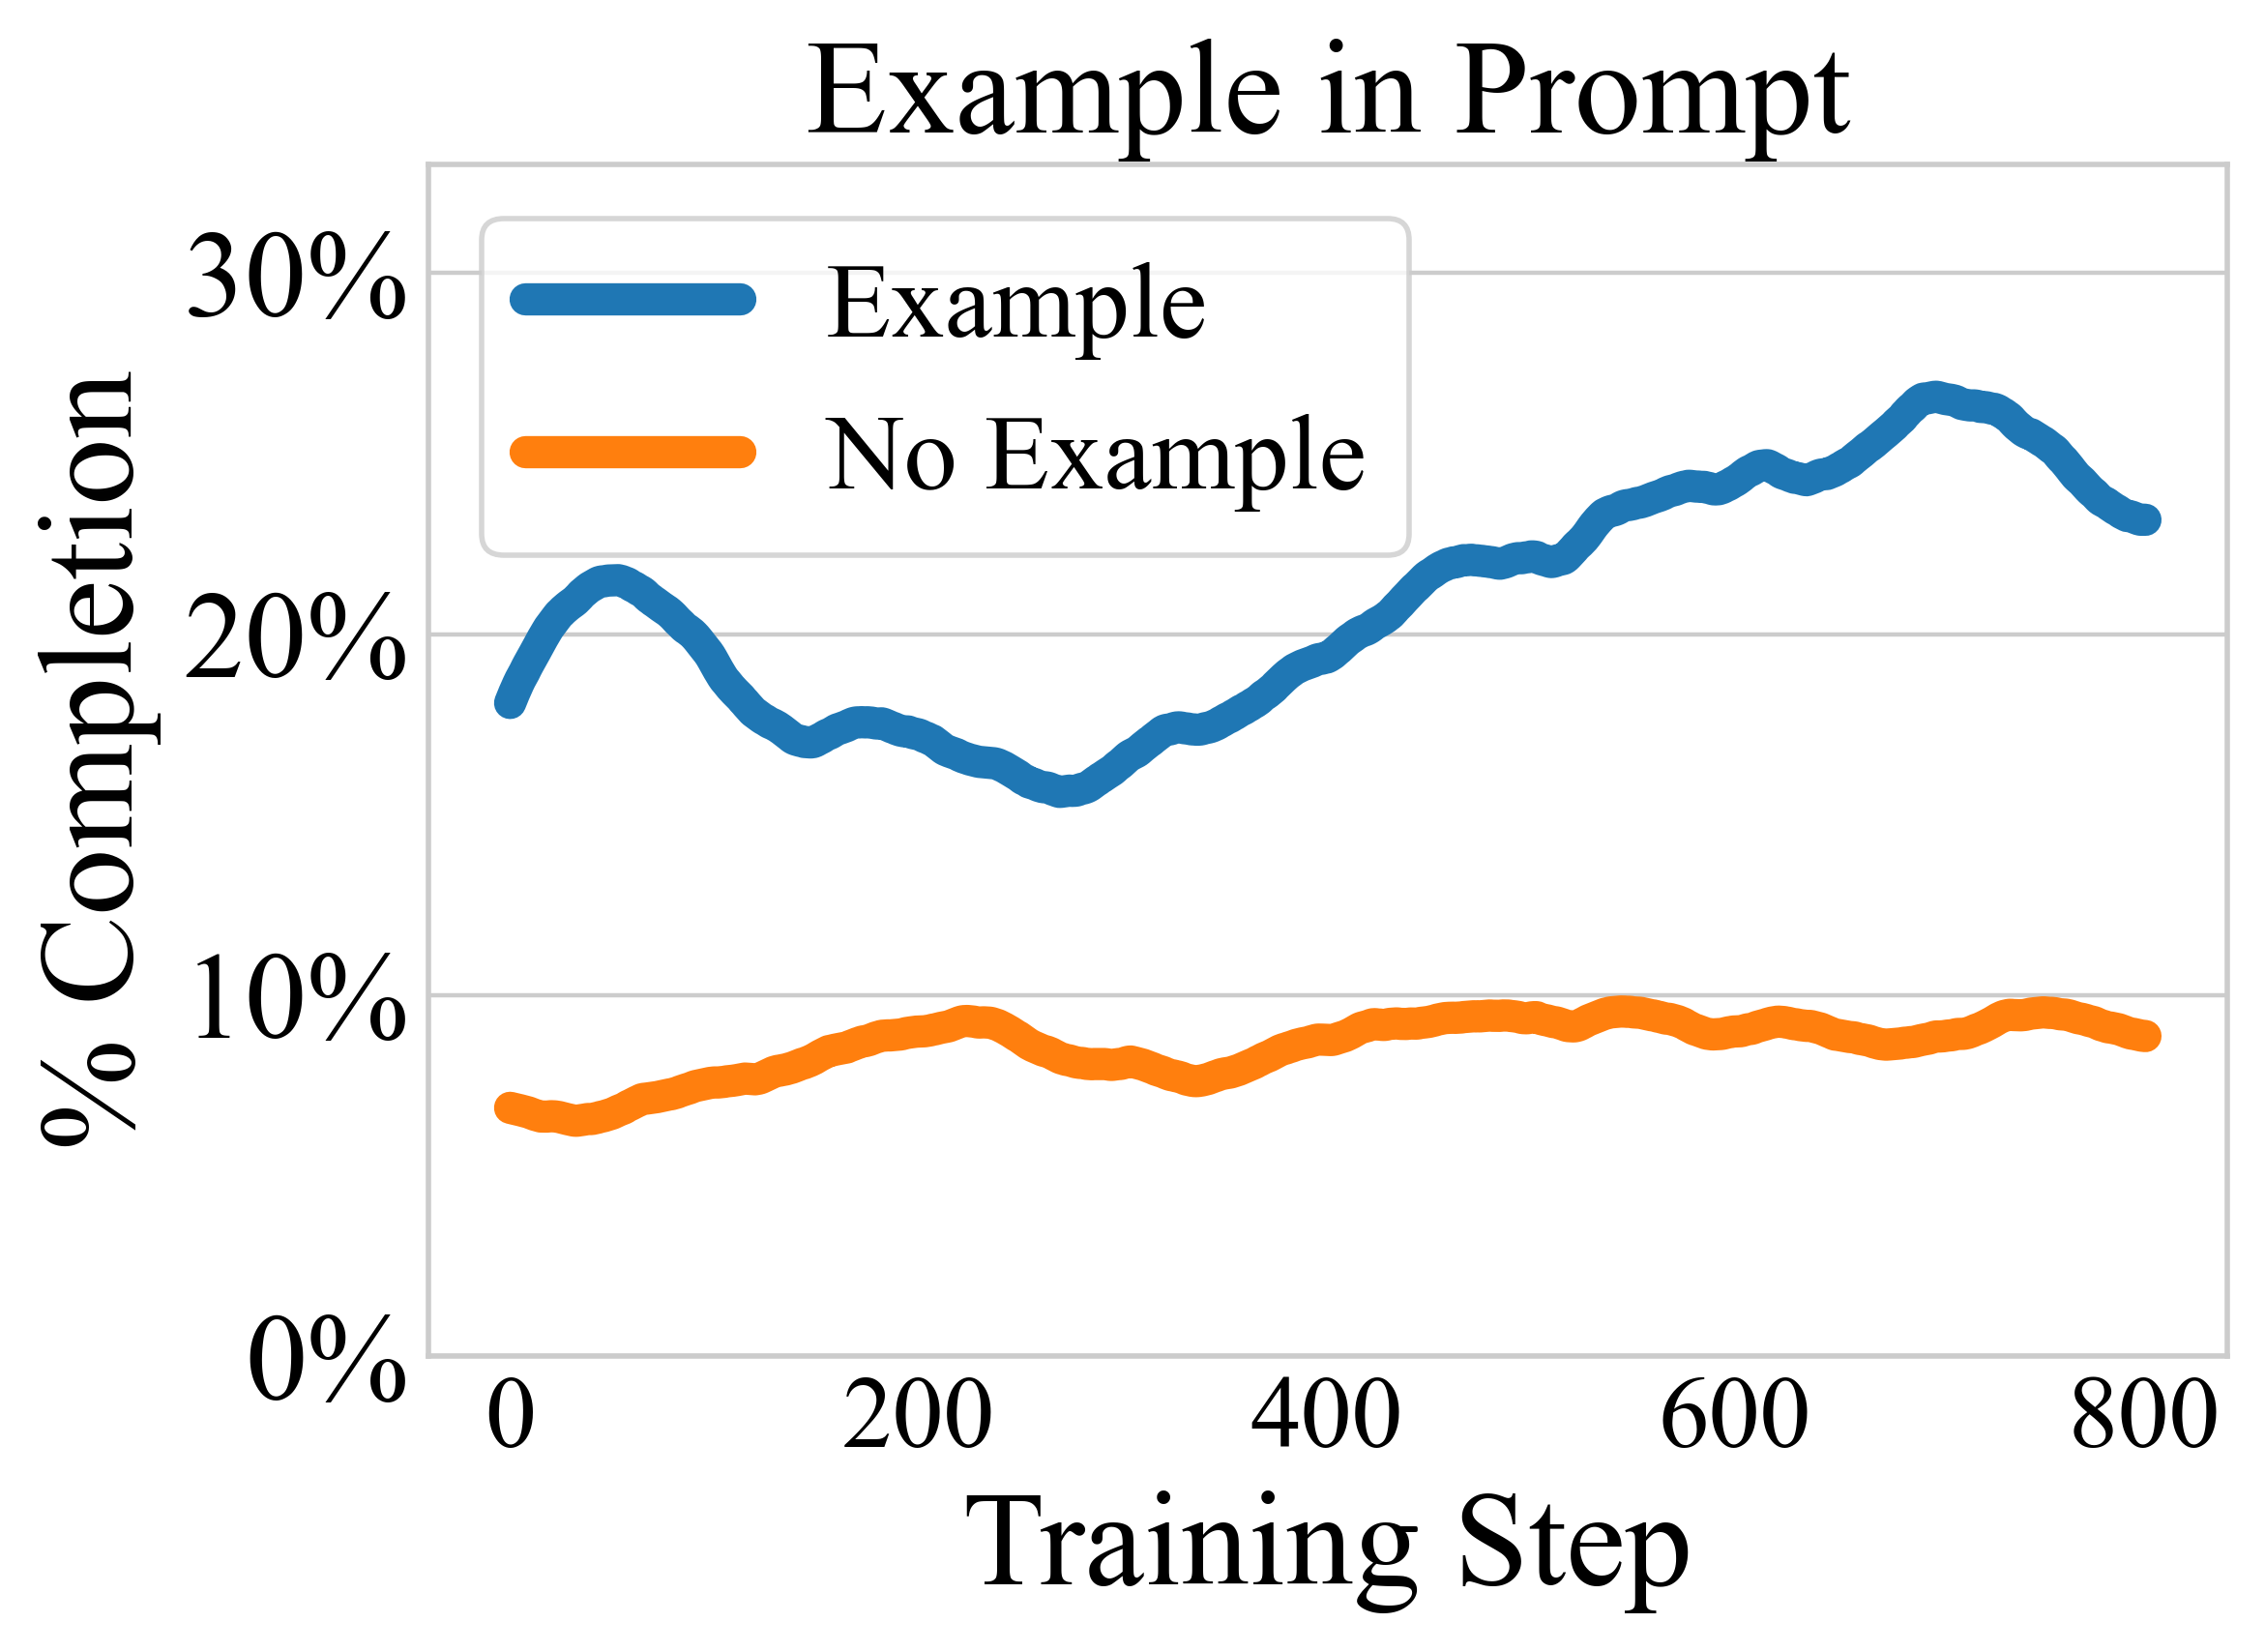

In [27]:
fig, ax = plt.subplots(dpi=DPI,figsize=(6,4))

# smooths
rewards_example_smooth = moving_average(moving_average(rewards_example, 100),50)
rewards_no_smooth = moving_average(moving_average(rewards_no, 100),50)
plt.plot(rewards_example_smooth,linewidth=6,label='Example')
plt.plot(rewards_no_smooth,linewidth=6,label='No Example')
plt.ylabel('% Completion',size=25)
plt.xlabel('Training Step',size=25)
#ax.set_xticks([250,790,2500,25000])
ax.tick_params(axis='x', which='major', labelsize=19)
ax.tick_params(axis='y', which='major', labelsize=23)


ax.set_yticks([0,.10,.20,.30])
ax.set_yticklabels(['0%','10%','20%','30%'])
#plt.ylim(-5,105)
plt.title('Example in Prompt',fontsize=25)
plt.legend(fontsize=20,loc='upper left')
plt.grid(axis='x')
plt.ylim(0,0.33)
plt.savefig('prompt_example.pdf',bbox_inches='tight')

### Major Training Run Figure

In [35]:
# data for w/example
run_example = api.run('qtcc-university-of-toronto/huggingface/llomzov2')
history_example = run_example.scan_history()
rewards_example = []
for row in history_example:
    if "train/reward" in row:
        rewards_example.append(row["train/reward"])
rewards_example = np.array(rewards_example)


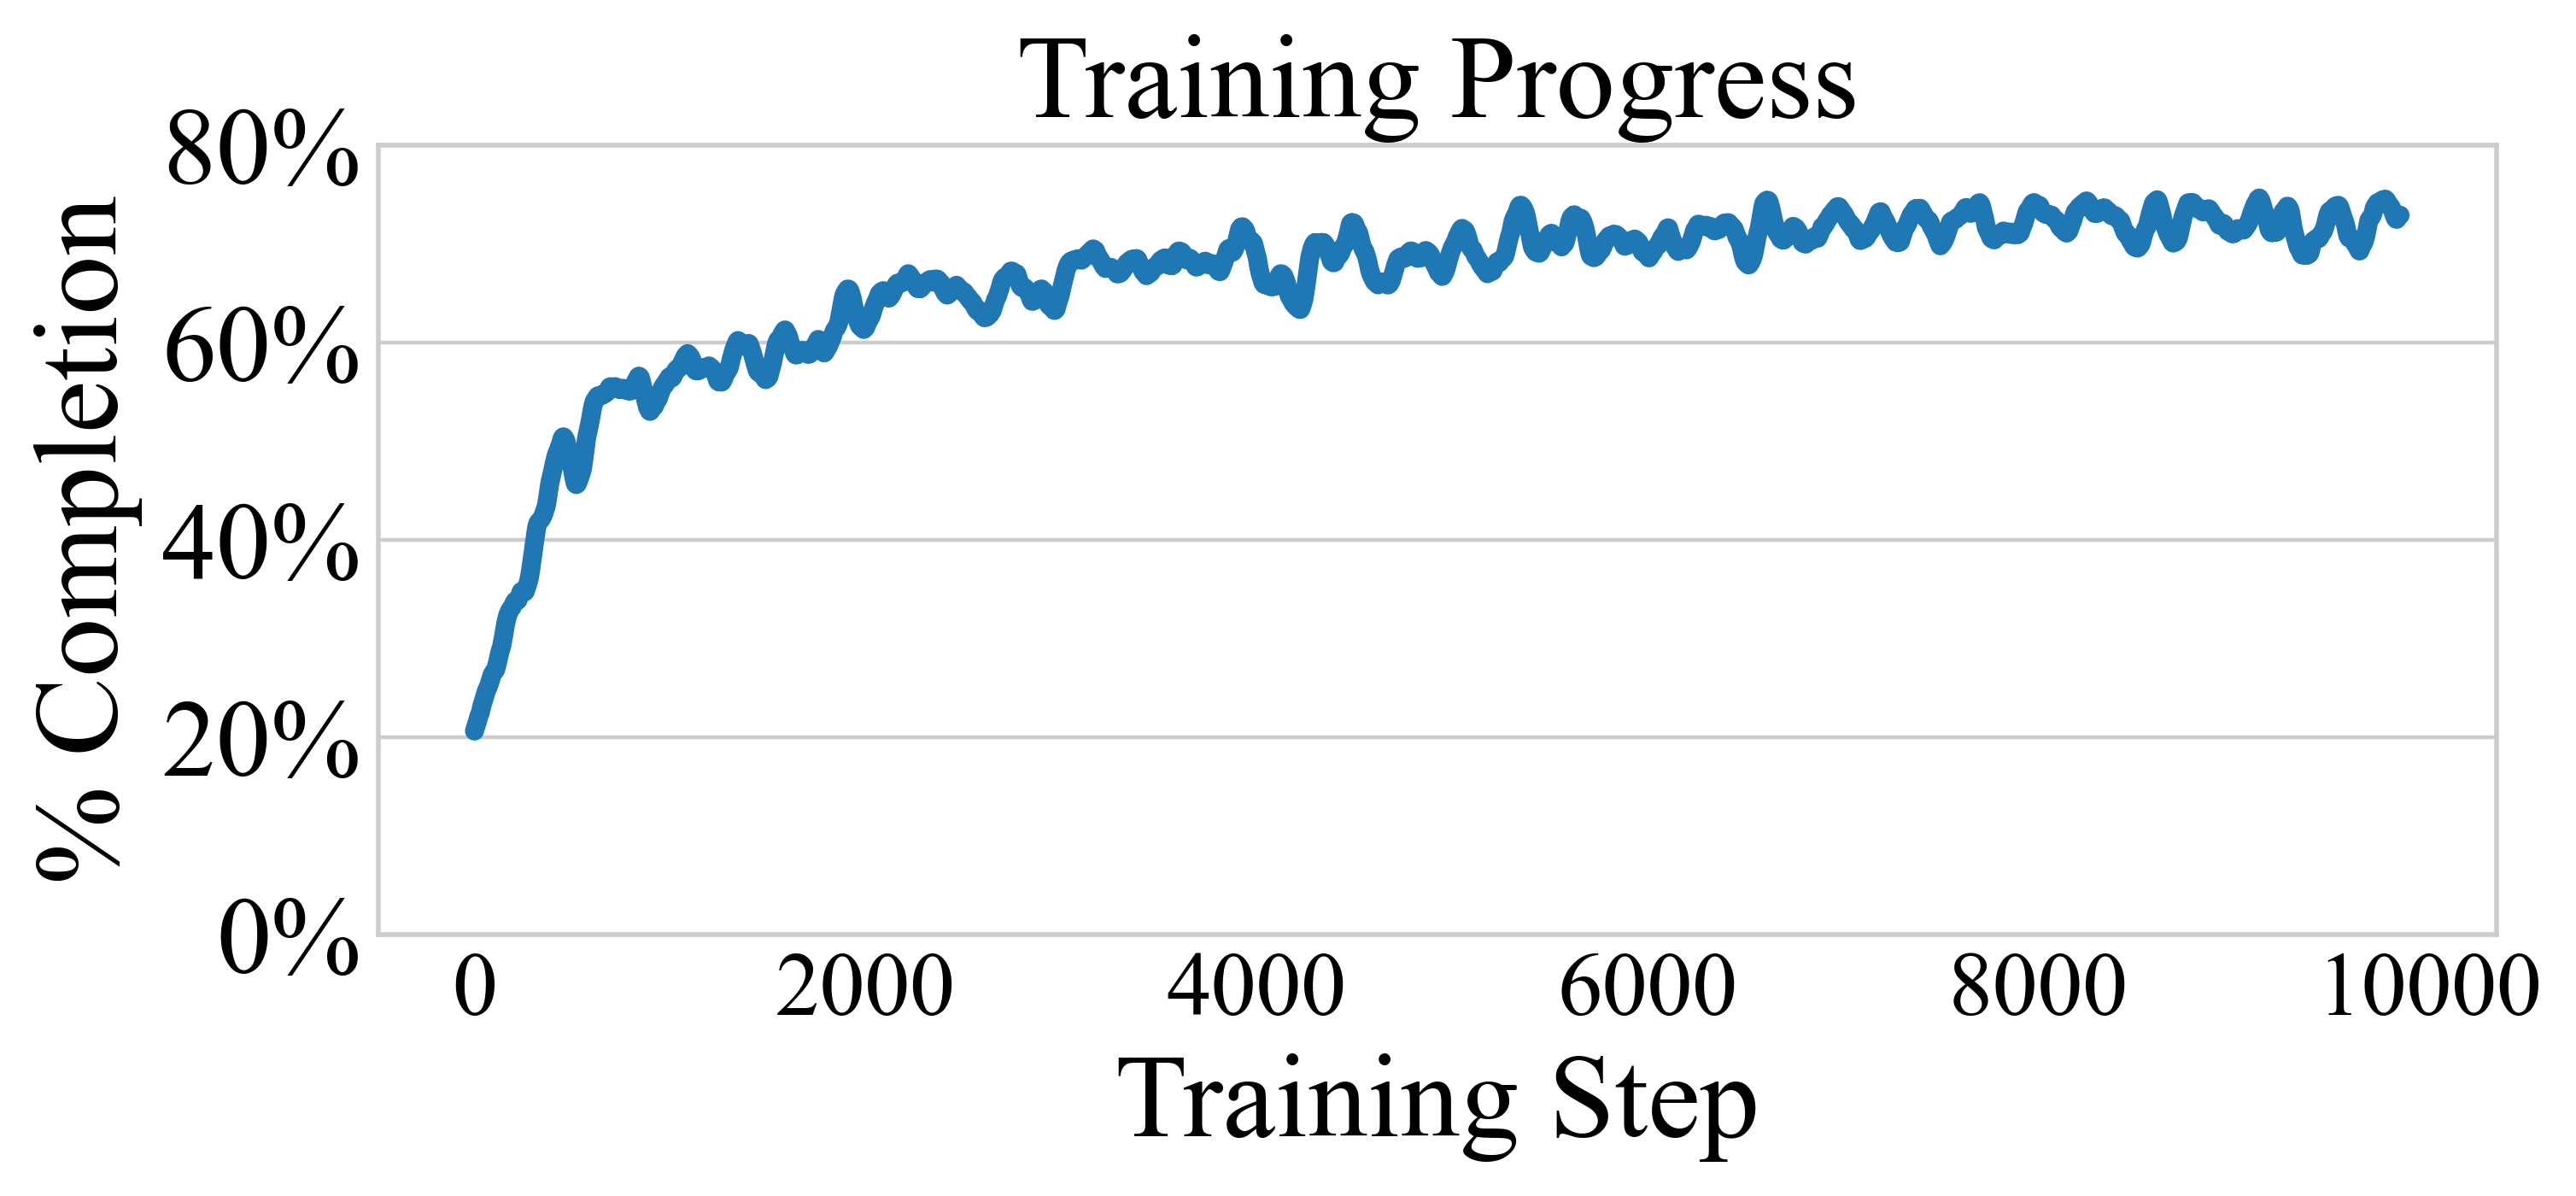

In [41]:
fig, ax = plt.subplots(dpi=DPI,figsize=(8,3))

# smooths
rewards_smooth = moving_average(moving_average(rewards_example, 100),50)
plt.plot(rewards_smooth,linewidth=4)
plt.ylabel('% Completion',size=25)
plt.xlabel('Training Step',size=25)
#ax.set_xticks([250,790,2500,25000])
ax.tick_params(axis='x', which='major', labelsize=19)
ax.tick_params(axis='y', which='major', labelsize=23)


ax.set_yticks([0,.20,.4,.6,.8])
ax.set_yticklabels(['0%','20%','40%','60%','80%'])
#plt.ylim(-5,105)
plt.title('Training Progress',fontsize=25)
plt.grid(axis='x')
plt.ylim(0,0.80)
plt.savefig('final_run.pdf',bbox_inches='tight')